In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import tensorflow as tf
from tensorflow import keras
from keras import layers
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\KIIT\Downloads\auto-mpg.csv")
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [3]:
df.shape

(398, 9)

In [4]:
#Exploratory Data Analysis (EDA)
#Let’s explore the dataset to understand its structure and identify any inconsistencies.
#First we will check the datatypes of the columns using df.info() function.
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
#Data Cleaning
#As per the df.info() part first we will deal with the horsepower column and then we will move toward the analysis part.
#df['horsepower'].unique()
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [7]:
print(df.shape)
df = df[df['horsepower'] != '?']
print(df.shape)

(398, 9)
(392, 9)


In [8]:
df['horsepower'] = df['horsepower'].astype(int)
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [9]:
df.nunique()

mpg             127
cylinders         5
displacement     81
horsepower       93
weight          346
acceleration     95
model year       13
origin            3
car name        301
dtype: int64

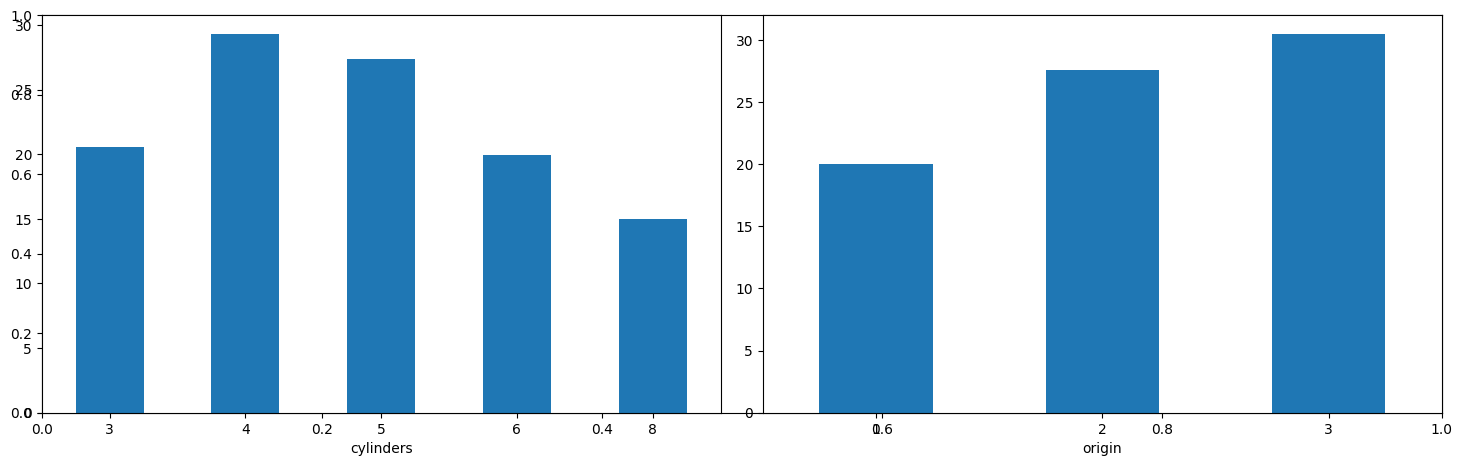

In [10]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
plt.subplots(figsize=(15, 5))
for i, col in enumerate(['cylinders', 'origin']):
    plt.subplot(1, 2, i+1)
    x = numeric_df.groupby(col).mean()['mpg']
    x.plot.bar()
    plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

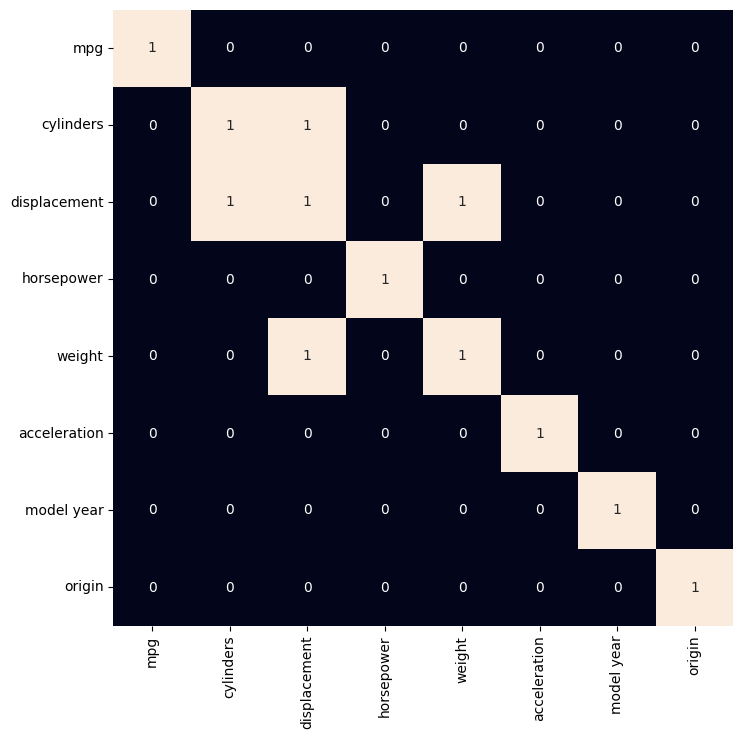

In [11]:
#Correlation Analysis
#Next, we explore the relationships between numeric features. We start by 
#plotting the correlation matrix to identify potential multicollinearity issues:
plt.figure(figsize=(8, 8)) 
sb.heatmap(numeric_df.corr() > 0.9, 
		annot=True, 
		cbar=False) 
plt.show()

In [12]:
df.drop('displacement',
        axis=1,
        inplace=True)

In [13]:
#Data Preprocessing
#Split Data into Features and Target
#We now split the dataset into features (independent variables) 
#and target (dependent variable):
from sklearn.model_selection import train_test_split
features = df.drop(['mpg', 'car name'], axis=1)
target = df['mpg'].values
X_train, X_val, \
    Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.2,
                                      random_state=22)
X_train.shape, X_val.shape

((313, 6), (79, 6))

In [14]:
#Create TensorFlow Data Pipeline
#We use TensorFlow to create a data pipeline for efficient training and validation. 
#This involves batching and prefetching the data for better performance:
AUTO = tf.data.experimental.AUTOTUNE
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, Y_train))
    .batch(32)
    .prefetch(AUTO)
)
val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, Y_val))
    .batch(32)
    .prefetch(AUTO)
)

In [15]:
#Define the Model
#We now define the model using Keras' Sequential API. The model consists of two fully connected layers, each with 256 neurons.
#Batch normalization layers are added for stable and faster training, and a dropout layer is included to prevent overfitting.
model = keras.Sequential
([
    layers.Dense(256, activation='relu', input_shape=[6]),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation='relu')
])

[<Dense name=dense, built=False>,
 <BatchNormalization name=batch_normalization, built=False>,
 <Dense name=dense_1, built=False>,
 <Dropout name=dropout, built=True>,
 <BatchNormalization name=batch_normalization_1, built=False>,
 <Dense name=dense_2, built=False>]

In [18]:
from keras.models import Sequential
from keras.layers import Dense
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(10,)))
model.add(Dense(1))
model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape']
)

In [19]:
model.summary(

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(6,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape']
)

In [24]:
from keras.models import Sequential
from keras.layers import Dense
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(6,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3292 - mape: 188.0393 - val_loss: 0.2554 - val_mape: 328.5311
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2587 - mape: 298.2032 - val_loss: 0.2611 - val_mape: 264.4906
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2528 - mape: 258.4758 - val_loss: 0.2518 - val_mape: 289.5933
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2517 - mape: 275.9062 - val_loss: 0.2534 - val_mape: 275.6248
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2506 - mape: 266.3364 - val_loss: 0.2513 - val_mape: 282.1745
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2502 - mape: 267.2592 - val_loss: 0.2541 - val_mape: 271.0893
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2493 - mape: 272.0243 - val_loss: 0.2519 - val_mape: 274.3841
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2485 - mape: 268.2222 - val_loss: 0.2553 - val_mape: 264.5130
Epoch 9/50
25/25 ━━━━━━

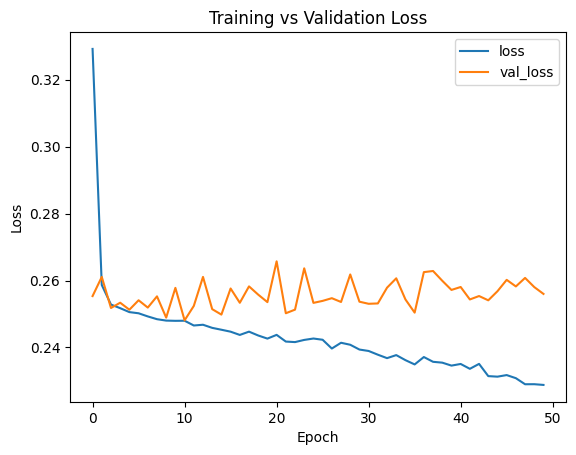

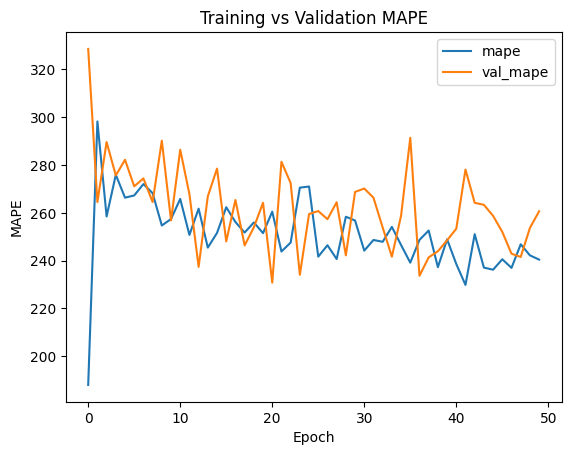

In [26]:
# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# 2️⃣ Example Dataset (replace with your own dataset)
# 6 input features
X = np.random.rand(1000,6)
y = np.random.rand(1000,1)

# Train / Validation split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)


# 3️⃣ Build Model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(6,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))


# 4️⃣ Compile Model
model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape']
)


# 5️⃣ Train Model (THIS CREATES history)
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    verbose=1
)


# 6️⃣ Convert Training History to DataFrame
history_df = pd.DataFrame(history.history)

print(history_df.head())


# 7️⃣ Plot Loss Graph
history_df[['loss','val_loss']].plot()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


# 8️⃣ Plot MAPE Graph
history_df[['mape','val_mape']].plot()
plt.title("Training vs Validation MAPE")
plt.xlabel("Epoch")
plt.ylabel("MAPE")
plt.show()

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 225.0651 - mape: 1179.3094 - val_loss: 108.3133 - val_mape: 568.8300
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 79.0457 - mape: 391.2372 - val_loss: 45.9120 - val_mape: 275.7758
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 35.5597 - mape: 192.9808 - val_loss: 35.5679 - val_mape: 172.1247
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.6324 - mape: 115.9278 - val_loss: 11.1787 - val_mape: 59.2187
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.0818 - mape: 66.5546 - val_loss: 13.3202 - val_mape: 76.8018
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.6361 - mape: 55.5811 - val_loss: 11.4383 - val_mape: 62.2872
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.5802 - mape: 50.1357 - val_loss: 11.5469 - val_mape: 63.8203
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.0874 - mape: 48.3696 - val_loss: 10.8901 - val_mape: 58.9690
Epoch 9/50
10

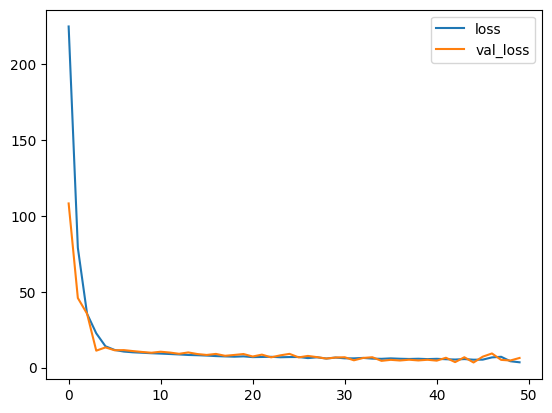

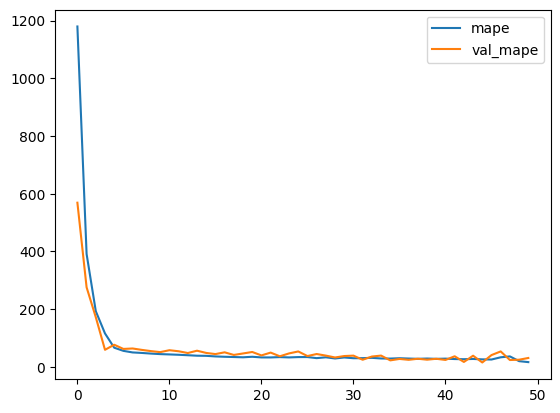

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
    Dense(64, activation='relu', input_shape=(6,)),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape']
)
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
inputs = Input(shape=(6,))
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
outputs = Dense(1)(x)
model = Model(inputs=inputs, outputs=outputs)
model.compile(
    loss='mae',
    optimizer='adam',
    metrics=['mape']
)
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds
)
import pandas as pd
import matplotlib.pyplot as plt
history_df = pd.DataFrame(history.history)
history_df[['loss','val_loss']].plot()
history_df[['mape','val_mape']].plot()
plt.show()